# REFMAP laboratory listening test 2 analysis: Exploratory data analysis — end response data

## Setup

In [80]:
# -*- coding: utf-8 -*-
import sys
import os
# Build a path from the notebook's parent directory to the python modules
module_path = os.path.abspath(os.path.join('..'))

# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)

# import statements
import numpy as np
import pandas as pd
from PyQt5.QtWidgets import QFileDialog, QApplication
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pingouin as pg
from numpy.random import Generator, PCG64
import soundscapy as sspy
from refmap_psychoacoustics.utils.format_helpers import display_round, round_trad
from refmap_psychoacoustics.utils.plotting_helpers import spiderplot, violin, violinsplit, violin_facet

In [73]:
# set plot parameters
sns.set_style('white')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams.update({'font.size': 16})
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['mathtext.fontset'] = 'stix'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE,
       labelsize=MEDIUM_SIZE)    # fontsize of the axes title and x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

mycolours = [(0, 102, 255), (0, 204, 153), (255, 0, 102), (74, 111, 152),
             (251, 164, 49), (204, 153, 255), (90, 192, 255), (80, 245, 233),
             (255, 90, 192), (164, 201, 242), (255, 254, 139), (255, 243, 255)]
mycolours = [tuple(shade/255 for shade in colour) for colour in mycolours]

numpy_randomGen = Generator(PCG64(303))

# enable copy-on-write mode for Pandas (will be default from Pandas 3.0)
pd.options.mode.copy_on_write = True

# check/open QApplication instance
if not QApplication.instance():
    app = QApplication(sys.argv)
else:
    app = QApplication.instance() 


# setup ipython autoreloading magic
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set the saveplots toggle to True if plot saving is desired:

In [4]:
saveplots=True

if saveplots:
    # select figure output save path
    outFigPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save plots '03 Experiment\Experiment 2\Analysis\Plots'")

    # create subfolders if not already existing
    try:
        os.mkdir(os.path.join(outFigPath, "svg"))
    except FileExistsError:
        pass

    try:
        os.mkdir(os.path.join(outFigPath, "pdf"))
    except FileExistsError:
        pass


## Functions

### General sigmoidal function for curve fitting

In [5]:
def sigmoid(x, q, k, v):
    y = 1 / (1 + q*np.exp(-k*x))**(1/v)
    return y

### General goodness-of-fit metrics for prediction models

In [6]:
def gof(data, predict, dof):
    residuals = data - predict  # residuals
    ss_res = np.sum(residuals**2)  # residual sum of squares
    ss_tot = np.sum((data - np.mean(data))**2)  # total sum of squares
    r_squared = 1 - (ss_res / ss_tot)  # coefficient of determination
    rse = np.sqrt(ss_res / dof)  # residual standard error
    return r_squared, rse

## Import data and organise

In [7]:
# import data
fileExts = "*.csv"

dataByStimFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest2_testdata_ByStim.csv",
                                                       caption=r"Open refmap_listest2_testdata_ByStim.csv in: \03 Experiment\Experiment 2\Analysis\PostProcess"))[0]
dataByStimTest = pd.read_csv(dataByStimFilePath, index_col=0)

subjDataFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest2_testdata_BySubj.csv",
                                                     caption=r"Open refmap_listest2_testdata_BySubj.csv in: \03 Experiment\Experiment 2\Analysis\PostProcess"))[0]
subjData = pd.read_csv(subjDataFilePath, index_col=False)

auxDataFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest2_auxdata.csv",
                                                   caption=r"Open refmap_listest2_auxdata.csv in: \03 Experiment\Experiment 2\Analysis\PostProcess"))[0]

auxData = pd.read_csv(auxDataFilePath, index_col=0)

In [8]:
# categorise columns

for dataset in [dataByStimTest, subjData]:
    dataset['UASProximity'] = pd.Categorical(dataset['UASProximity'], ["Baseline", "Far", "Near"])
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Residential", "Park (high)",
                                                                   "Highway (low)", "Streetside square",
                                                                   "Highway"])
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight", "Delivery"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "T150"])
    dataset['UASStart'] = pd.Categorical(dataset['UASStart'], ["Baseline", "Left", "Right"])

for dataset in [auxData]:
    dataset['UASProximity'] = pd.Categorical(dataset['UASProximity'], ["Far", "Near"])
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Overflight", "Delivery"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["H520", "T150"])


## Exploratory data analysis

In this section, exploratory plots are used to examine the Part A data for information and possible trends.

Responses are analysed using violin and scatter plots, segregating the data by the categorical variables UAS LAeq, Ambient environment type, UAS/Ambient signal-noise-ratio, UAS type, and flight operation type.

Noticeability of UAS is investigated using violin and scatter plots.

### Ambient environment annoyance and soundscape distribution comparison

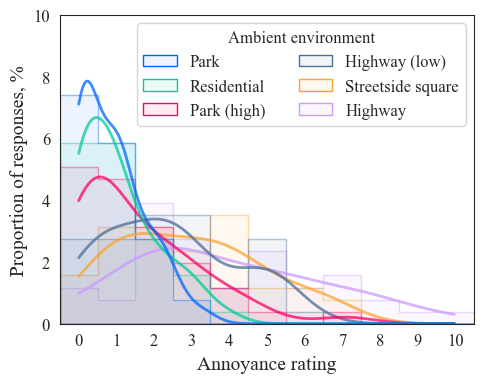

In [74]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.histplot(data=subjData[subjData['UASType'] == 'Baseline'],
             x='Annoyance', hue='AmbientEnv', stat='percent',
             discrete=True, palette=mycolours[0:6], kde=True,
             multiple='layer', element='step', ax=ax, alpha=0.07,
             legend=True, line_kws={'linewidth':2, 'alpha':0.75})

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=2, title="Ambient environment")

ax.set(xticks=range(0, 11), yticks=range(0, 12, 2), xlim=[-0.5, 10.5],
       ylabel="Proportion of responses, %",
       xlabel="Annoyance rating")

# reduce the alpha of the histogram outlines to make them less visually dominant
# without affecting the alpha of the filled areas or of the KDE lines
edge_alpha = 0.4
mycolours_outline = [(*color, edge_alpha) for color in mycolours[0:6]]

ii = 5
for child in ax.get_children():
    if isinstance(child, mpl.collections.FillBetweenPolyCollection):
       # set the edge colour using the mycolours_outline list which has reduced alpha
       child.set_edgecolor(mycolours_outline[ii])
       ii -= 1

if saveplots:
    
    filename = "AmbAnnoyProp"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()

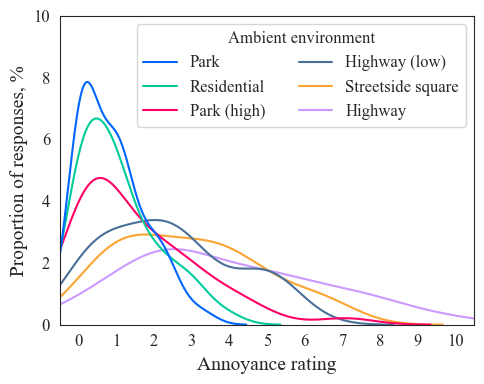

In [75]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.kdeplot(data=subjData[subjData['UASType'] == 'Baseline'],
             x='Annoyance', hue='AmbientEnv',
             palette=mycolours[0:6],
             multiple='layer', ax=ax,
             legend=True)

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=2, title="Ambient environment")

ax.set(xticks=range(0, 11), xlim=[-0.5, 10.5], yticks=np.arange(0, 0.12, 0.02),
       yticklabels=np.arange(0, 12, 2),
       ylabel="Proportion of responses, %",
       xlabel="Annoyance rating")

if saveplots:

    filename = "AmbAnnoyPropKDE"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()

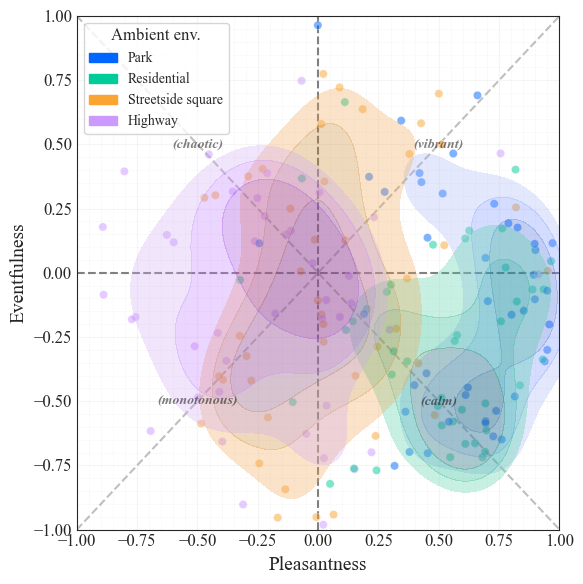

In [77]:
fig, ax = plt.subplots(figsize=(6, 6))

data = subjData.loc[(subjData['UASType'] == 'Baseline') &
                    (subjData['AmbientRef'] != "Park3Loud") &
                    (subjData['AmbientRef'] != "BusyStreet6Quiet"), :]
# recategorise AmbientEnv to omit the two excluded references
data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Residential",
                                                         "Streetside square", "Highway"])
isop = sspy.plotting.density_plot(data=data,
                                  x='Pleasantness', y='Eventfulness', hue='AmbientEnv',
                                  palette=mycolours[0:2] + mycolours[4:6], legend=True,
                                  simple_density=True, simple_density_alpha=0.3,
                                  fill=True, simple_density_levels=4,
                                  ax=ax, apply_styling=False, title=None,
                                  diagonal_lines=True)

# reduce the alpha on all grid lines
isop.grid(alpha=0.075, which='both')

# reduce the alpha on all plotted points but not the density contours
for child in ax.get_children():
    if isinstance(child, mpl.collections.PathCollection):
        child.set_alpha(0.5)

legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=1, title="Ambient env.", fontsize=10)

if saveplots:

    filename = "AmbPleasEvent"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()


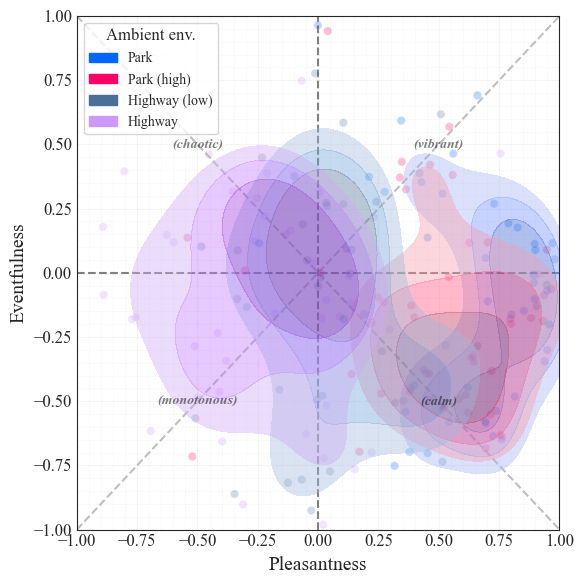

In [78]:
fig, ax = plt.subplots(figsize=(6, 6))

data = subjData.loc[(subjData['UASType'] == 'Baseline') &
                    (subjData['AmbientRef'] != "QuietStreet7") &
                    (subjData['AmbientRef'] != "BusyStreet8"), :]
# recategorise AmbientEnv to omit the two excluded reference`s
data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Park (high)",
                                                         "Highway (low)", "Highway"])
isop = sspy.plotting.density_plot(data=data,
                                  x='Pleasantness', y='Eventfulness', hue='AmbientEnv',
                                  palette=[mycolours[0]] + mycolours[2:4] + [mycolours[5]],
                                  legend=True, simple_density=True, simple_density_alpha=0.4,
                                  fill=True, simple_density_levels=4,
                                  ax=ax, apply_styling=False, title=None,
                                  incl_scatter=True, diagonal_lines=True)

# reduce the alpha on all grid lines
isop.grid(alpha=0.075, which='both')


legend = ax.get_legend()
handles = legend.legend_handles
labels = [t.get_text() for t in legend.texts]
legend.remove()

ax.legend(handles, labels, ncol=1, title="Ambient env.", fontsize=10)
ax.set(xlim=[-1.0, 1.0], ylim=[-1.0, 1.0])

# reduce the alpha on all plotted points but not the density contours
for child in ax.get_children():
    if isinstance(child, mpl.collections.PathCollection):
        child.set_alpha(0.25)

if saveplots:

    filename = "AmbPleasEventParkHighway"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()


### Annoyance distribution relative to UAS proximity

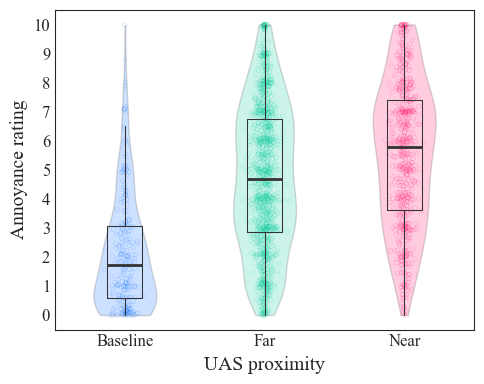

In [81]:
fig, ax = violin(subjData, x='UASProximity', y='Annoyance', palette=mycolours,
                 figsize=(5, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS proximity",
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:

    filename = "AnnoyByProx"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

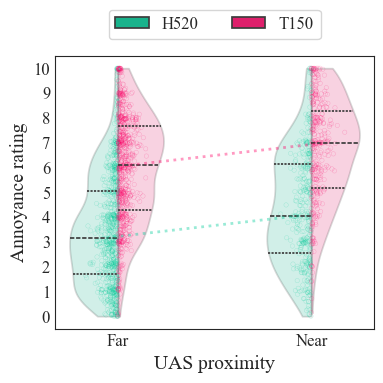

In [82]:
data = subjData[subjData['UASType'] != 'Baseline']
# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])

fig, ax = violinsplit(data=data, x='UASProximity', y='Annoyance', hue='UASType',
                      palette=mycolours[1:], med_trace=True,
                      figsize=(4, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS proximity",
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:

    filename = "AnnoyByProxByType"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

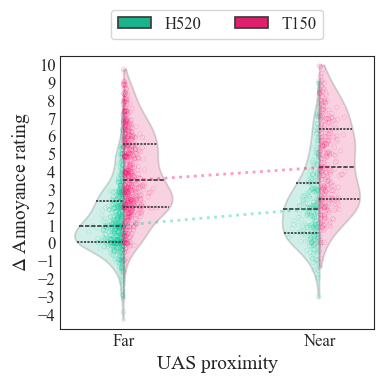

In [85]:
data = subjData[subjData['UASType'] != 'Baseline']
# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])

fig, ax = violinsplit(data=data, x='UASProximity', y='dAnnoyance', hue='UASType',
                      palette=mycolours[1:], med_trace=True,
                      figsize=(4, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(-4, 11), xlabel="UAS proximity",
       ylabel="$\\Delta$ Annoyance rating", ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByType"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

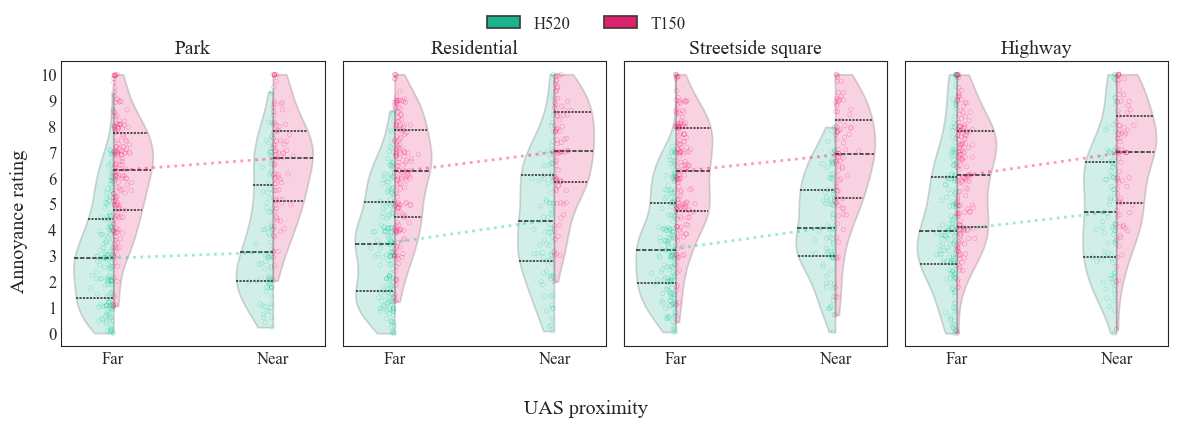

In [86]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv',
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {col}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='Annoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(12, 4), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Annoyance rating",
                        yticks=range(0, 11))

fig.tight_layout()

if saveplots:

    filename = "AnnoyByProxByTypeByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

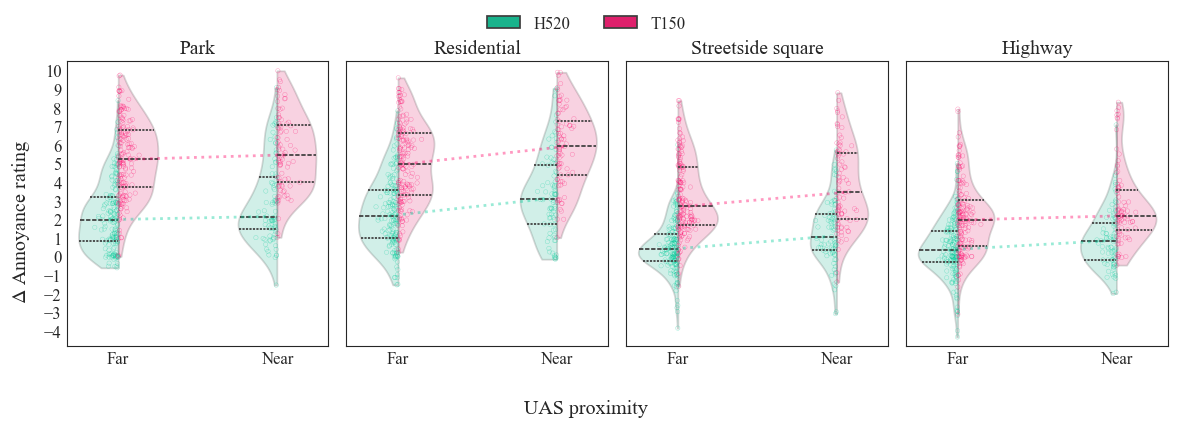

In [88]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=None,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {col}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(12, 4), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="$\\Delta$ Annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByTypeByAmb"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

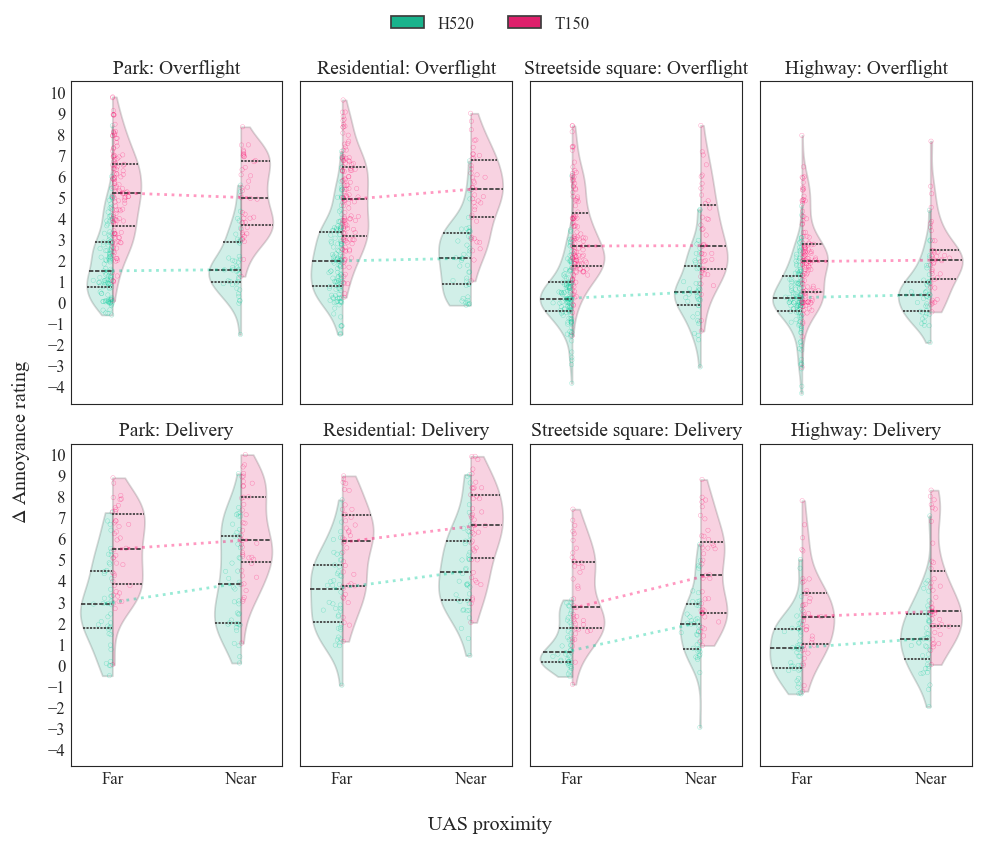

In [89]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', facet_row='UASOperation',
                        plot_func=violinsplit,
                        title_fmt="{col}: {row}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(10, 8), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="$\\Delta$ Annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByTypeByOpByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

### Annoyance distribution relative to UAS operation

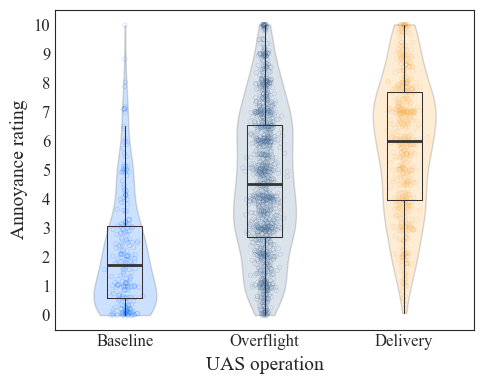

In [90]:
fig, ax = violin(subjData, x='UASOperation', y='Annoyance', palette=[mycolours[0]] + mycolours[3:],
                 figsize=(5, 4), alpha_pt=0.4, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS operation",
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:
    
    filename = "AnnoyByOp"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

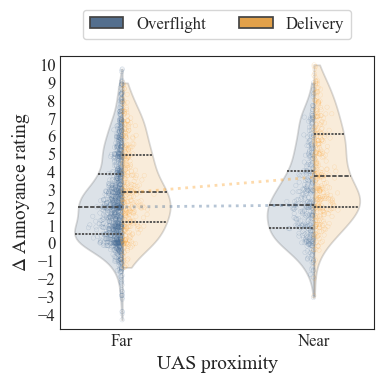

In [92]:
data = subjData[subjData['UASType'] != 'Baseline']
# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])

fig, ax = violinsplit(data=data, x='UASProximity', y='dAnnoyance', hue='UASOperation',
                      palette=mycolours[3:], med_trace=True,
                      figsize=(4, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(-4, 11), xlabel="UAS proximity",
       ylabel="$\\Delta$ Annoyance rating", ylim=[-4.8, 10.5])

if saveplots:
    
    filename = "dAnnoyByProxByOp"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

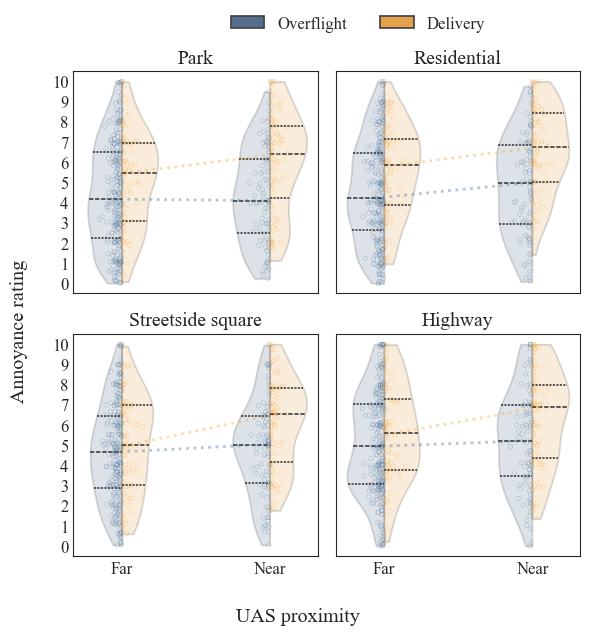

In [93]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=2,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {value}",
                        legend_bbox_to_anchor=(0.6, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='Annoyance', hue='UASOperation',
                        palette=mycolours[3:], med_trace=True,
                        figsize=(6, 6), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="Annoyance rating",
                        yticks=range(0, 11))

if saveplots:

    filename = "AnnoyByProxByOpByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

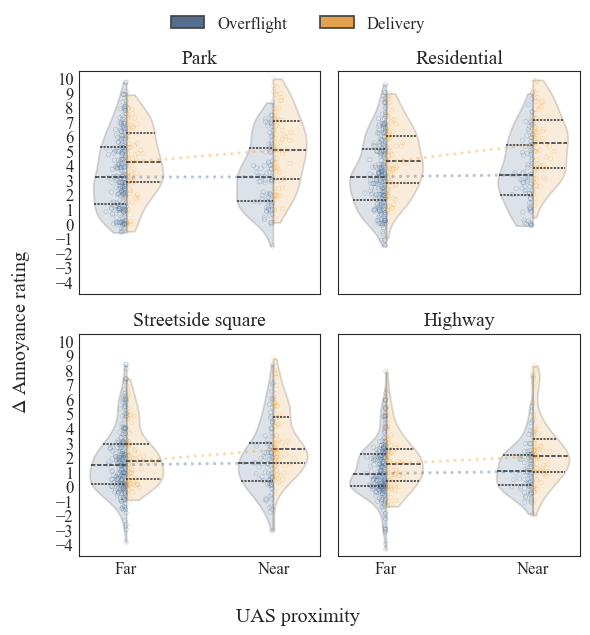

In [94]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=2,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {value}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASOperation',
                        palette=mycolours[3:], med_trace=True,
                        figsize=(6, 6), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS proximity", ylabel="$\\Delta$ Annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByOpByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

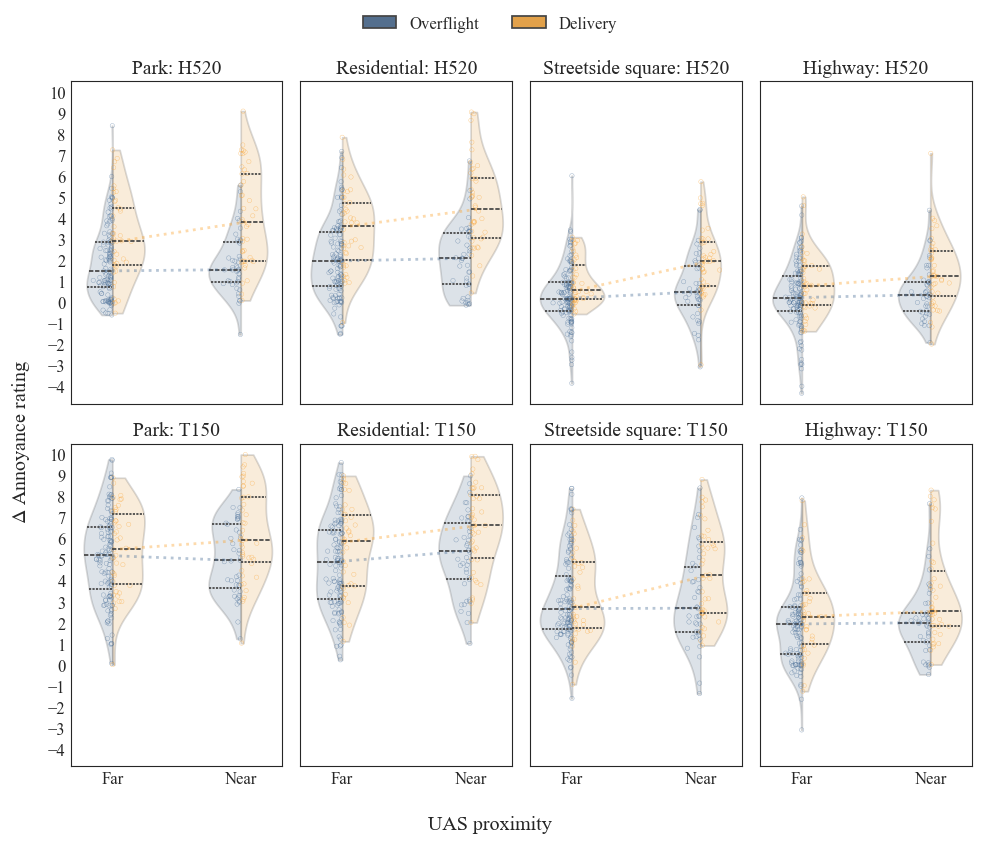

In [95]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])
data['UASOperation'] = pd.Categorical(data['UASOperation'], ["Overflight", "Delivery"])


fig, axs = violin_facet(data=data, facet_col='AmbientEnv', facet_row='UASType',
                        plot_func=violinsplit,
                        title_fmt="{col}: {row}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASProximity', y='dAnnoyance', hue='UASOperation',
                        palette=mycolours[3:], med_trace=True,
                        figsize=(10, 8), alpha_pt=0.7, size_pt=10,
                        xlabel="UAS proximity", ylabel="$\\Delta$ Annoyance rating",
                        yticks=range(-4, 11))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5])

if saveplots:

    filename = "dAnnoyByProxByOpByTypeByAmb"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

### Annoyance distribution relative to UAS events

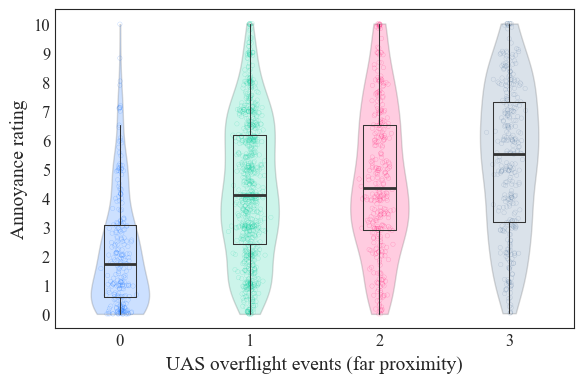

In [96]:
fig, ax = violin(subjData[subjData['UASOperation'] != 'Delivery'],
                 x='UASEvents', y='Annoyance', palette=mycolours,
                 figsize=(6, 4), alpha_pt=0.3, size_pt=10)

ax.set(yticks=range(0, 11), xlabel="UAS overflight events (far proximity)", xticklabels=["0", "1", "2", "3"],
       ylabel="Annoyance rating", ylim=[-0.5, 10.5])

if saveplots:

    filename = "AnnoyByEvents"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

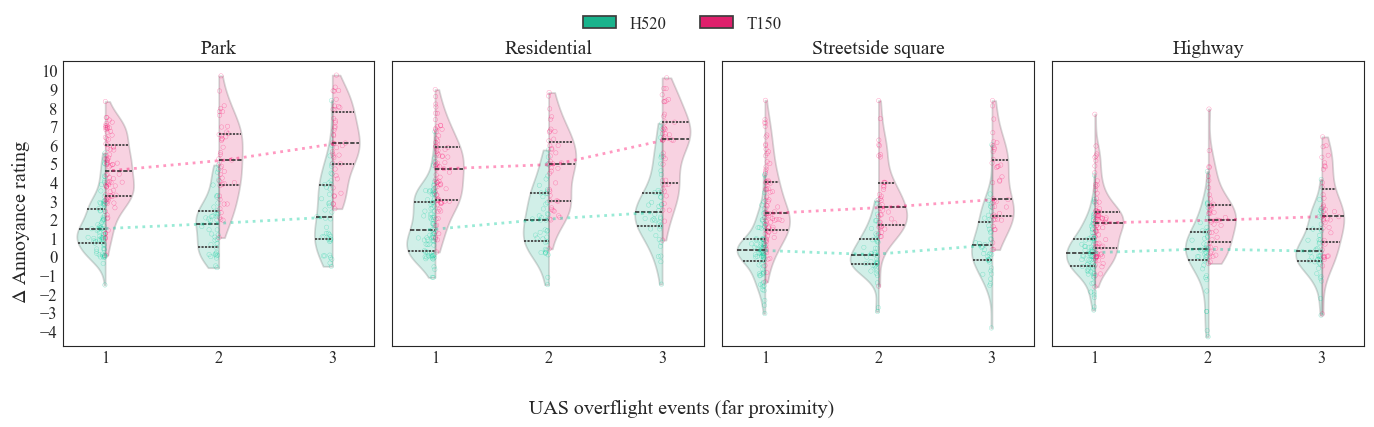

In [97]:
data = subjData.loc[(subjData['UASType'] != 'Baseline') &
                    (subjData['AmbientRef'] != 'Park3Loud') &
                    (subjData['AmbientRef'] != 'BusyStreet6Quiet') &
                    (subjData['UASOperation'] != 'Delivery'), :]

# recategorise to omit baseline
data['UASProximity'] = pd.Categorical(data['UASProximity'], ["Far", "Near"])
data['UASType'] = pd.Categorical(data['UASType'], ["H520", "T150"])

fig, axs = violin_facet(data=data, facet_col='AmbientEnv', wrap_cols=None,
                        plot_func=violinsplit,
                        title_fmt="Ambient env: {col}",
                        legend_bbox_to_anchor=(0.5, 1.05),
                        sharex=True, sharey=True,
                        x='UASEvents', y='dAnnoyance', hue='UASType',
                        palette=mycolours[1:], med_trace=True,
                        figsize=(14, 4), alpha_pt=0.5, size_pt=10,
                        xlabel="UAS overflight events (far proximity)",
                        ylabel="$\\Delta$ Annoyance rating",
                        yticks=range(-4, 11), xticks=range(0, 3))

for ax in axs.flatten():
    ax.set(ylim=[-4.8, 10.5], xticklabels=["1", "2", "3"])

if saveplots:

    filename = "dAnnoyByEventsByTypeByAmb"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

## Sound quality analysis

### SQM spider plots

In [10]:
df_SQM = auxData.loc[(auxData.index.str.contains("asphalt")) &
                     (auxData['UASStart'] == "Left") &
                     (auxData['UASEvents'] == 1), :]

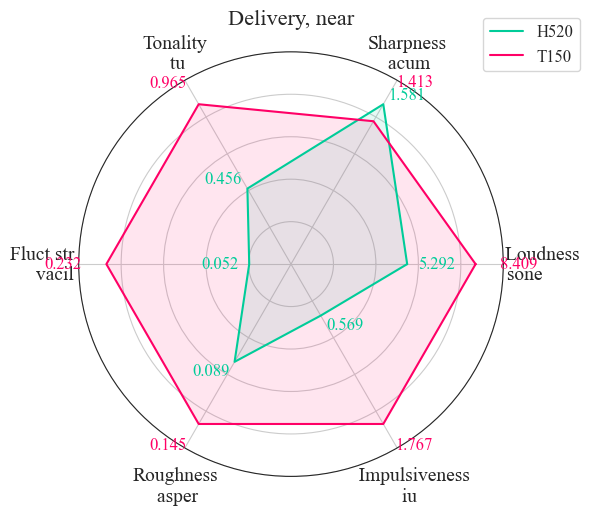

In [ ]:
data=pd.DataFrame({
        'UASType': df_SQM['UASType'].unique(),
        '        Loudness\n sone': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                              (df_SQM['UASProximity'] == 'Near'),
                                              'LoudECMAPowAvg'].values,
        'Sharpness\n acum\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                           (df_SQM['UASProximity'] == 'Near'),
                                           'SharpvBISO105Ex'].values,
        'Tonality\n tu\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                        (df_SQM['UASProximity'] == 'Near'),
                                        'TonalECMA05Ex'].values,
        'Fluct str       \n vacil   ': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                                   (df_SQM['UASProximity'] == 'Near'),
                                                   'FluctOV10Ex'].values,
        '\n\nRoughness\n asper': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                              (df_SQM['UASProximity'] == 'Near'),
                                              'RoughECMA10Ex'].values,
        '\n\n   Impulsiveness\n iu': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                                   (df_SQM['UASProximity'] == 'Near'),
                                                   'ImpulsLoudWZAvg'].values
    })

max_values = {col: data[col].max() for col in data.columns if col != 'UASType'}

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))

spiderplot(df=data, id_column='UASType', categories=None, ax=ax,
           title="Delivery, near", limits=None, max_values=max_values,
           scalers=None, padding=1.15, annotate=True,
           offset=True, fmt='{:.3f}', labelsize=12,
           ticksize=14, legendsize=12, titlesize=16, palette=mycolours[1:])

if saveplots:

    filename = "UASsqmDeliveryNear"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

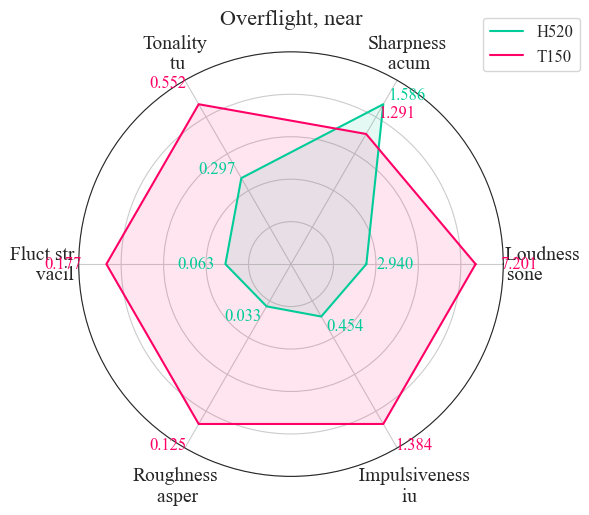

In [ ]:
data=pd.DataFrame({
        'UASType': df_SQM['UASType'].unique(),
        '        Loudness\n sone': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                              (df_SQM['UASProximity'] == 'Near'),
                                              'LoudECMAPowAvg'].values,
        'Sharpness\n acum\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                           (df_SQM['UASProximity'] == 'Near'),
                                           'SharpvBISO105Ex'].values,
        'Tonality\n tu\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                        (df_SQM['UASProximity'] == 'Near'),
                                        'TonalECMA05Ex'].values,
        'Fluct str       \n vacil   ': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                                   (df_SQM['UASProximity'] == 'Near'),
                                                   'FluctOV10Ex'].values,
        '\n\nRoughness\n asper': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                              (df_SQM['UASProximity'] == 'Near'),
                                              'RoughECMA10Ex'].values,
        '\n\n   Impulsiveness\n iu': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                                   (df_SQM['UASProximity'] == 'Near'),
                                                   'ImpulsLoudWZAvg'].values
    })

max_values = {col: data[col].max() for col in data.columns if col != 'UASType'}

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))

spiderplot(df=data, id_column='UASType', categories=None, ax=ax,
           title="Overflight, near", limits=None, max_values=max_values,
           scalers=None, padding=1.15, annotate=True,
           offset=True, fmt='{:.3f}', labelsize=12,
           ticksize=14, legendsize=12, titlesize=16, palette=mycolours[1:])

if saveplots:

    filename = "UASsqmOverflightNear"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

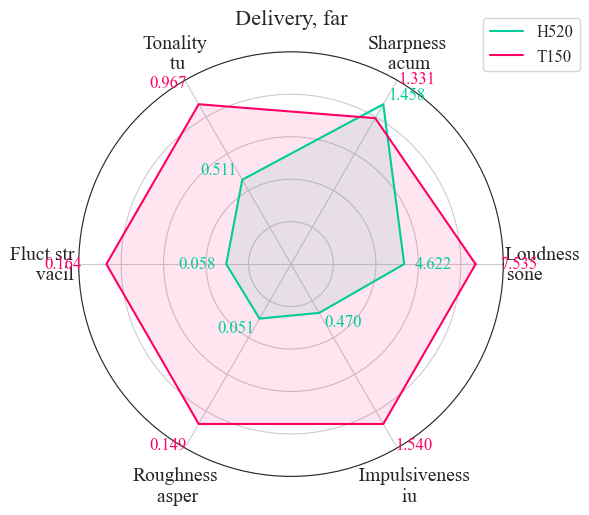

In [50]:
data=pd.DataFrame({
        'UASType': df_SQM['UASType'].unique(),
        '        Loudness\n sone': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                              (df_SQM['UASProximity'] == 'Far'),
                                              'LoudECMAPowAvg'].values,
        'Sharpness\n acum\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                           (df_SQM['UASProximity'] == 'Far'),
                                           'SharpvBISO105Ex'].values,
        'Tonality\n tu\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                        (df_SQM['UASProximity'] == 'Far'),
                                        'TonalECMA05Ex'].values,
        'Fluct str       \n vacil   ': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                                   (df_SQM['UASProximity'] == 'Far'),
                                                   'FluctOV10Ex'].values,
        '\n\nRoughness\n asper': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                              (df_SQM['UASProximity'] == 'Far'),
                                              'RoughECMA10Ex'].values,
        '\n\n   Impulsiveness\n iu': df_SQM.loc[(df_SQM['UASOperation'] == 'Delivery') &
                                                   (df_SQM['UASProximity'] == 'Far'),
                                                   'ImpulsLoudWZAvg'].values
    })

max_values = {col: data[col].max() for col in data.columns if col != 'UASType'}

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))

spiderplot(df=data, id_column='UASType', categories=None, ax=ax,
           title="Delivery, far", limits=None, max_values=max_values,
           scalers=None, padding=1.15, annotate=True,
           offset=True, fmt='{:.3f}', labelsize=12,
           ticksize=14, legendsize=12, titlesize=16, palette=mycolours[1:])

if saveplots:

    filename = "UASsqmDeliveryFar"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

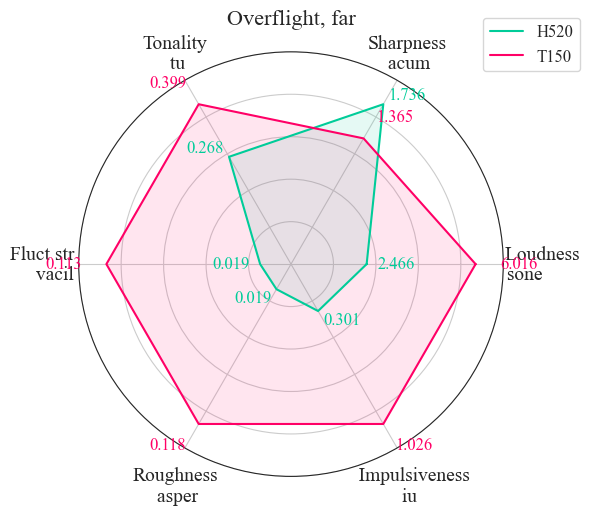

In [51]:
data=pd.DataFrame({
        'UASType': df_SQM['UASType'].unique(),
        '        Loudness\n sone': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                              (df_SQM['UASProximity'] == 'Far'),
                                              'LoudECMAPowAvg'].values,
        'Sharpness\n acum\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                           (df_SQM['UASProximity'] == 'Far'),
                                           'SharpvBISO105Ex'].values,
        'Tonality\n tu\n': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                        (df_SQM['UASProximity'] == 'Far'),
                                        'TonalECMA05Ex'].values,
        'Fluct str       \n vacil   ': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                                   (df_SQM['UASProximity'] == 'Far'),
                                                   'FluctOV10Ex'].values,
        '\n\nRoughness\n asper': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                              (df_SQM['UASProximity'] == 'Far'),
                                              'RoughECMA10Ex'].values,
        '\n\n   Impulsiveness\n iu': df_SQM.loc[(df_SQM['UASOperation'] == 'Overflight') &
                                                   (df_SQM['UASProximity'] == 'Far'),
                                                   'ImpulsLoudWZAvg'].values
    })

max_values = {col: data[col].max() for col in data.columns if col != 'UASType'}

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))

spiderplot(df=data, id_column='UASType', categories=None, ax=ax,
           title="Overflight, far", limits=None, max_values=max_values,
           scalers=None, padding=1.15, annotate=True,
           offset=True, fmt='{:.3f}', labelsize=12,
           ticksize=14, legendsize=12, titlesize=16, palette=mycolours[1:])

if saveplots:

    filename = "UASsqmOverflightFar"

    fig.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    fig.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

plt.show()

### SQM correlation plots

#### Proxy metrics for ambient environments

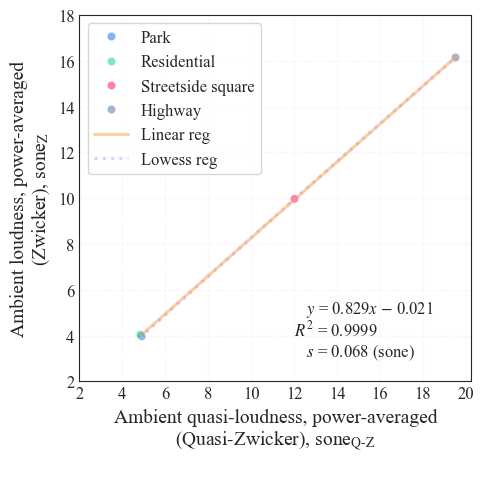

In [98]:
fig, ax = plt.subplots(figsize=(5, 5))

data = dataByStimTest[dataByStimTest['UASType']
                      == 'Baseline'].loc[(dataByStimTest['AmbientRef']
                                          != 'Park3Loud') &
                                         (dataByStimTest['AmbientRef']
                                          != 'BusyStreet6Quiet'), :]

data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Residential",
                                                         "Streetside square", "Highway"])

# fit linear regression model 
mod = sm.OLS(data['LoudISO1PowAvg'], sm.add_constant(data['LoudQZ5321PowAvg']), hasconst=True)
res = mod.fit()

sns.scatterplot(data=data, x='LoudQZ5321PowAvg', y='LoudISO1PowAvg', hue='AmbientEnv',
                palette=mycolours[0:4], alpha=0.5, ax=ax)
sns.regplot(data=data, x='LoudQZ5321PowAvg', y='LoudISO1PowAvg', ci=None,
            scatter=False, seed=303, n_boot=2000, color=mycolours[4], lowess=False, label="Linear reg",
            line_kws={'linestyle': '-', 'alpha': 0.5})
sns.regplot(data=data, x='LoudQZ5321PowAvg', y='LoudISO1PowAvg',
            scatter=False, seed=303, n_boot=2000, color=mycolours[5], lowess=True, label="Lowess reg",
            line_kws={'linestyle': ':', 'alpha': 0.5})
ax.grid(alpha=0.15, linestyle='--')
ax.set(ylabel="Ambient loudness, power-averaged" + "\n" + "(Zwicker), " + r"sone$_\text{Z}$",
       xlabel="Ambient quasi-loudness, power-averaged" + "\n" + "(Quasi-Zwicker), " + r"sone$_\text{Q-Z}$" + "\n",
       yticks=range(2, 20, 2), xticks=range(2, 22, 2))
ax.text(x=12, y=4, s=r"$R^2$ = " + str(round(res.rsquared, 4)))
# calculate standard error of the estimate for the regression line
ax.text(x=12, y=3.1, s=r"   $s$ = " + str(round(np.sqrt(res.mse_resid), 4)) + " (sone)")

# generate string for intercept sign
if np.sign(res.params.iloc[0]) < 0:
    icept = r"$ - $"
else:
    icept = r"$ + $"

ax.text(x=12, y=5,
        s=r"   $y$ = " + str(round(res.params.iloc[1], 3)) + r"$x$" + " " + icept + " " + str(abs(round(res.params.iloc[0], 3))))
ax.legend()

if saveplots:

    filename = "SQscatAmbNISO1vNQZ5321"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()

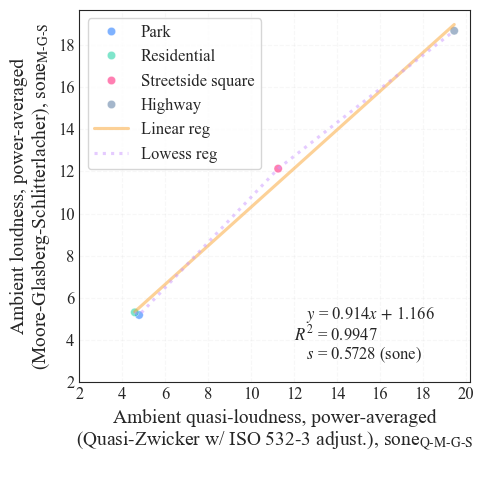

In [99]:
fig, ax = plt.subplots(figsize=(5, 5))

data = dataByStimTest[dataByStimTest['UASType']
                      == 'Baseline'].loc[(dataByStimTest['AmbientRef']
                                          != 'Park3Loud') &
                                         (dataByStimTest['AmbientRef']
                                          != 'BusyStreet6Quiet'), :]

data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Residential",
                                                         "Streetside square", "Highway"])

# fit linear regression model 
mod = sm.OLS(data['LoudISO3PowAvg'], sm.add_constant(data['LoudQZ5323PowAvg']), hasconst=True)
res = mod.fit()

sns.scatterplot(data=data, x='LoudQZ5323PowAvg', y='LoudISO3PowAvg', hue='AmbientEnv',
                palette=mycolours[0:4], alpha=0.5, ax=ax)
sns.regplot(data=data, x='LoudQZ5323PowAvg', y='LoudISO3PowAvg', ci=None,
            scatter=False, seed=303, n_boot=2000, color=mycolours[4], lowess=False, label="Linear reg",
            line_kws={'linestyle': '-', 'alpha': 0.5})
sns.regplot(data=data, x='LoudQZ5323PowAvg', y='LoudISO3PowAvg',
            scatter=False, seed=303, n_boot=2000, color=mycolours[5], lowess=True, label="Lowess reg",
            line_kws={'linestyle': ':', 'alpha': 0.5})
ax.grid(alpha=0.15, linestyle='--')
ax.set(ylabel="Ambient loudness, power-averaged" + "\n" + "(Moore-Glasberg-Schlitterlacher), " + r"sone$_\text{M-G-S}$",
       xlabel="Ambient quasi-loudness, power-averaged" + "\n" + "(Quasi-Zwicker w/ ISO 532-3 adjust.), " + r"sone$_\text{Q-M-G-S}$" + "\n",
       yticks=range(2, 20, 2), xticks=range(2, 22, 2))
ax.text(x=12, y=4, s=r"$R^2$ = " + str(round(res.rsquared, 4)))
# calculate standard error of the estimate for the regression line
ax.text(x=12, y=3.1, s=r"   $s$ = " + str(round(np.sqrt(res.mse_resid), 4)) + " (sone)")

# generate string for intercept sign
if np.sign(res.params.iloc[0]) < 0:
    icept = r"$ - $"
else:
    icept = r"$ + $"

ax.text(x=12, y=5,
        s=r"   $y$ = " + str(round(res.params.iloc[1], 3)) + r"$x$" + " " + icept + " " + str(abs(round(res.params.iloc[0], 3))))
ax.legend()

if saveplots:

    filename = "SQscatAmbNISO3vNQZ5323"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()

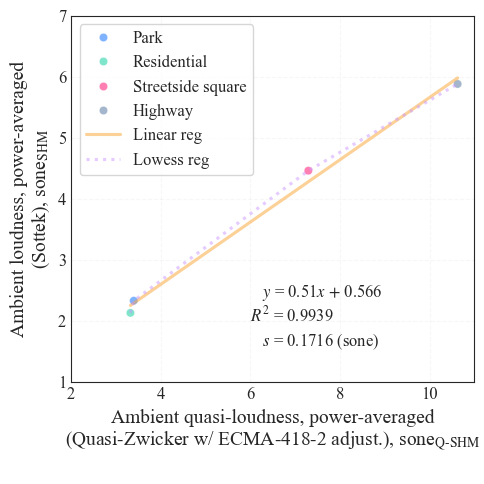

In [105]:
fig, ax = plt.subplots(figsize=(5, 5))

data = dataByStimTest[dataByStimTest['UASType']
                      == 'Baseline'].loc[(dataByStimTest['AmbientRef']
                                          != 'Park3Loud') &
                                         (dataByStimTest['AmbientRef']
                                          != 'BusyStreet6Quiet'), :]

data['AmbientEnv'] = pd.Categorical(data['AmbientEnv'], ["Park", "Residential",
                                                         "Streetside square", "Highway"])

# fit linear regression model 
mod = sm.OLS(data['LoudECMAPowAvg'], sm.add_constant(data['LoudQZ4182PowAvg']), hasconst=True)
res = mod.fit()

sns.scatterplot(data=data, x='LoudQZ4182PowAvg', y='LoudECMAPowAvg', hue='AmbientEnv',
                palette=mycolours[0:4], alpha=0.5, ax=ax)
sns.regplot(data=data, x='LoudQZ4182PowAvg', y='LoudECMAPowAvg', ci=None,
            scatter=False, seed=303, n_boot=2000, color=mycolours[4], lowess=False, label="Linear reg",
            line_kws={'linestyle': '-', 'alpha': 0.5})
sns.regplot(data=data, x='LoudQZ4182PowAvg', y='LoudECMAPowAvg',
            scatter=False, seed=303, n_boot=2000, color=mycolours[5], lowess=True, label="Lowess reg",
            line_kws={'linestyle': ':', 'alpha': 0.5})
ax.grid(alpha=0.15, linestyle='--')
ax.set(ylabel="Ambient loudness, power-averaged" + "\n" + "(Sottek), " + r"sone$_\text{SHM}$",
       xlabel="Ambient quasi-loudness, power-averaged" + "\n" + "(Quasi-Zwicker w/ ECMA-418-2 adjust.), " + r"sone$_\text{Q-SHM}$" + "\n",
       yticks=range(1, 8, 1), xticks=range(2, 12, 2))
ax.text(x=6, y=2, s=r"$R^2$ = " + str(round(res.rsquared, 4)))
# calculate standard error of the estimate for the regression line
ax.text(x=6, y=1.6, s=r"   $s$ = " + str(round(np.sqrt(res.mse_resid), 4)) + " (sone)")

# generate string for intercept sign
if np.sign(res.params.iloc[0]) < 0:
    icept = r"$ - $"
else:
    icept = r"$ + $"

ax.text(x=6, y=2.4,
        s=r"   $y$ = " + str(round(res.params.iloc[1], 3)) + r"$x$" + " " + icept + " " + str(abs(round(res.params.iloc[0], 3))))
ax.legend()

if saveplots:

    filename = "SQscatAmbNECMAvNQZ4182"

    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf')

plt.show()